# M3 & M4 — Conformal Prediction

---
## Section 1 — Setup

In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Environment ───────────────────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Datasets ──────────────────────────────────────────────────────────────────
DATASETS = {
    "SKAB": {
        "npy_dir":     "npy_skab",
        "hf_dataset":  "skab-anomaly-detection",
        "window_size": 30,
        "n_features":  8,
    },
    "NAB": {
        "npy_dir":     "npy_nab",
        "hf_dataset":  "nab-anomaly-detection",
        "window_size": 50,
        "n_features":  1,
    },
}

# ── Conformal Prediction ───────────────────────────────────────────────────────
ALPHA = 0.05        # significance level → FPR ≤ 5% guaranteed on calibration set

# ── M3 HP: Dense AE + CP (best from M1, dropout_p fixed at 0.0 → deterministic)
M3_HP = {
    "SKAB": {"latent_dim": 32, "lr": 0.001},
    "NAB":  {"latent_dim": 32, "lr": 0.002},
}

# ── M4 HP: LSTM AE + CP (best from M2, dropout_p fixed at 0.0 → deterministic)
M4_HP = {
    "SKAB": {"latent_dim": 32, "lr": 0.001, "hidden_dim": 64},
    "NAB":  {"latent_dim": 64, "lr": 0.001, "hidden_dim": 64},
}
LSTM_HIDDEN_DIM = 64   # fallback if ds not in M4_HP

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS     = 150
PATIENCE   = 20
BATCH_SIZE = 256

# ── Outputs ───────────────────────────────────────────────────────────────────
import os
RESULTS_FILE = "outputs/baseline_results.json"
OUTPUT_DIR   = "outputs"
CKPT_DIR     = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

# ── HF Hub ────────────────────────────────────────────────────────────────────
PUSH_TO_HUB = True

# ── W&B ───────────────────────────────────────────────────────────────────────
USE_WANDB     = True
WANDB_PROJECT = "iot-ad-cp"


In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_recall_curve,
)
from huggingface_hub import HfApi, create_repo

# ── Credentials ────────────────────────────────────────────────────────────────
def _secret(key):
    """Read a Colab secret by name (takes exactly 1 arg)."""
    from google.colab import userdata
    return userdata.get(key)

if IN_COLAB:
    HF_USERNAME  = _secret("HF_USERNAME")
    HF_TOKEN     = _secret("HF_TOKEN")
    WANDB_KEY    = _secret("WANDB_API_KEY")
    WANDB_ENTITY = _secret("WANDB_ENTITY")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY, relogin=True)
        else:
            print("⚠ WANDB_API_KEY not set in Colab secrets — W&B offline")
            os.environ["WANDB_MODE"] = "offline"
else:
    from dotenv import load_dotenv
    load_dotenv()
    HF_USERNAME  = os.getenv("HF_USERNAME")
    HF_TOKEN     = os.getenv("HF_TOKEN")
    WANDB_KEY    = os.getenv("WANDB_API_KEY", "")
    WANDB_ENTITY = os.getenv("WANDB_ENTITY", "")
    if USE_WANDB:
        import wandb
        if WANDB_KEY:
            wandb.login(key=WANDB_KEY, relogin=True)
        else:
            print("⚠ WANDB_API_KEY not set in .env — running offline")
            os.environ["WANDB_MODE"] = "offline"

MODEL_REPO_ID = f"{HF_USERNAME}/iot-ad-models"
api = HfApi()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"HF repo: {MODEL_REPO_ID}")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eyyoub (eyyoub-um) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Device : cuda
HF repo: ayyoubsoullami/iot-ad-models


In [4]:
try:
    create_repo(
        repo_id   = MODEL_REPO_ID,
        repo_type = "model",
        token     = HF_TOKEN,
        private   = False,
        exist_ok  = True,
    )
    print(f"HF model repo ready: https://huggingface.co/{MODEL_REPO_ID}")
except Exception as e:
    print(f"HF repo check skipped: {e}")


HF model repo ready: https://huggingface.co/ayyoubsoullami/iot-ad-models


---
## Section 2 — Data Loading

In [5]:
def _load_local(ds_name, cfg):
    """Load npy arrays from local disk. Returns dict or None."""
    npy_dir = cfg["npy_dir"]
    if not os.path.isdir(npy_dir):
        print(f"  Local '{npy_dir}' not found.")
        return None
    arrays = {}
    for name in ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"]:
        path = os.path.join(npy_dir, f"{name}.npy")
        if not os.path.exists(path):
            print(f"  Missing {path}.")
            return None
        arrays[name] = np.load(path)
    print(f"  Loaded {ds_name} from local disk — "
          f"train {arrays['X_train'].shape}, val {arrays['X_val'].shape}, "
          f"test {arrays['X_test'].shape}")
    return arrays


def _load_from_hub(ds_name, cfg):
    """Load windowed arrays from HF Hub. Returns dict or None.

    Dataset structure: splits 'train' / 'validation' / 'test',
    columns feature_0 .. feature_{n-1} (each a window-length list) + 'label'.
    """
    from datasets import load_dataset as hf_load
    repo = f"{HF_USERNAME}/{cfg['hf_dataset']}"
    print(f"  Fetching {ds_name} from HF Hub: {repo} ...")
    try:
        ds = hf_load(repo)
    except Exception as e:
        print(f"  HF Hub load failed for {ds_name}: {e}")
        return None

    n_feat = cfg["n_features"]

    def to_np(split):
        X = np.stack(
            [np.array(split[f"feature_{i}"]) for i in range(n_feat)], axis=-1
        ).astype(np.float32)
        y = np.array(split["label"], dtype=np.int8)
        return X, y

    try:
        X_train, y_train = to_np(ds["train"])
        X_val,   y_val   = to_np(ds["validation"])
        X_test,  y_test  = to_np(ds["test"])
    except Exception as e:
        print(f"  Failed to parse HF Hub data for {ds_name}: {e}")
        return None

    print(f"  Loaded {ds_name} from HF Hub — "
          f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
    return dict(
        X_train=X_train, X_val=X_val, X_test=X_test,
        y_train=y_train, y_val=y_val, y_test=y_test,
    )


data = {}
for ds_name, cfg in DATASETS.items():
    print(f"\n{'='*55}\n{ds_name}")
    arr = _load_local(ds_name, cfg)
    if arr is None:
        print(f"  Local npy not found — fetching from HF Hub ...")
        arr = _load_from_hub(ds_name, cfg)
    if arr is not None:
        data[ds_name] = arr
        print(f"  y_test anomaly rate: "
              f"{arr['y_test'].mean():.3%}  ({arr['y_test'].sum()} / {len(arr['y_test'])})")
    else:
        print(f"  ERROR: could not load {ds_name}.")

print(f"\nDatasets loaded: {list(data.keys())}")


SKAB
  Local 'npy_skab' not found.
  Local npy not found — fetching from HF Hub ...
  Fetching SKAB from HF Hub: ayyoubsoullami/skab-anomaly-detection ...
  Loaded SKAB from HF Hub — train (23588, 30, 8), val (3345, 30, 8), test (19786, 30, 8)
  y_test anomaly rate: 67.507%  (13357 / 19786)

NAB
  Local 'npy_nab' not found.
  Local npy not found — fetching from HF Hub ...
  Fetching NAB from HF Hub: ayyoubsoullami/nab-anomaly-detection ...
  Loaded NAB from HF Hub — train (229577, 50, 1), val (30354, 50, 1), test (97101, 50, 1)
  y_test anomaly rate: 35.555%  (34524 / 97101)

Datasets loaded: ['SKAB', 'NAB']


---
## Section 3 — Model Architectures

In [6]:
class DenseAE(nn.Module):
    """Dense autoencoder. With dropout_p=0 + model.eval() → fully deterministic."""

    def __init__(self, input_dim: int, latent_dim: int = 32,
                 dropout_p: float = 0.0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, latent_dim), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(64, 128),        nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, input_dim), nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


In [7]:
class LSTMAE(nn.Module):
    """LSTM autoencoder. With dropout_p=0 + model.eval() → fully deterministic."""

    def __init__(self, n_features: int, hidden_dim: int = 64,
                 latent_dim: int = 32, dropout_p: float = 0.0):
        super().__init__()
        self.window_size = None  # set at first forward pass

        self.enc_lstm = nn.LSTM(n_features, hidden_dim, batch_first=True)
        self.enc_drop = nn.Dropout(dropout_p)
        self.enc_fc   = nn.Linear(hidden_dim, latent_dim)

        self.dec_fc   = nn.Linear(latent_dim, hidden_dim)
        self.dec_drop = nn.Dropout(dropout_p)
        self.dec_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.dec_out  = nn.Sequential(nn.Linear(hidden_dim, n_features), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.window_size is None:
            self.window_size = x.shape[1]
        _, (h_n, _) = self.enc_lstm(x)
        z = self.enc_fc(self.enc_drop(h_n.squeeze(0)))
        d = self.dec_drop(self.dec_fc(z))
        d_rep, _ = self.dec_lstm(d.unsqueeze(1).repeat(1, self.window_size, 1))
        return self.dec_out(d_rep)


---
## Section 4 — Training (Deterministic)

In [8]:
def push_checkpoint(api, model, filename, model_repo_id, hf_token):
    """Save model state locally; push to HF Hub if enabled."""
    local_path = os.path.join(CKPT_DIR, filename)
    torch.save(model.state_dict(), local_path)
    if not PUSH_TO_HUB:
        return
    try:
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = f"checkpoints/{filename}",
            repo_id         = model_repo_id,
            repo_type       = "model",
            token           = hf_token,
        )
    except Exception as e:
        print(f"  HF push failed: {e}")


def train_det(model, X_train, X_val, run_label, is_lstm=False, wandb_run=None):
    """Train a deterministic autoencoder with early stopping.

    Parameters
    ----------
    is_lstm : bool — if True input stays 3-D; if False it is flattened to 2-D
    Returns : (model, train_losses, val_losses, best_val_loss)
    """
    def _prep(X):
        t = torch.from_numpy(X).float()
        return t if is_lstm else t.reshape(len(t), -1)

    t_dl = DataLoader(TensorDataset(_prep(X_train)), batch_size=BATCH_SIZE, shuffle=True)
    v_dl = DataLoader(TensorDataset(_prep(X_val)),   batch_size=BATCH_SIZE)
    opt  = torch.optim.Adam(model.parameters(), lr=
                            (M4_HP if is_lstm else M3_HP).get(run_label, {}).get("lr", 1e-3))
    crit = nn.MSELoss()

    best_val, best_state, patience_ctr = float("inf"), None, 0
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0.0
        for (xb,) in t_dl:
            xb = xb.to(device)
            loss = crit(model(xb), xb)
            opt.zero_grad(); loss.backward(); opt.step()
            t_loss += loss.item() * len(xb)
        t_loss /= len(X_train)
        train_losses.append(t_loss)

        model.eval()
        with torch.no_grad():
            v_loss = sum(
                crit(xb.to(device), model(xb.to(device))).item() * len(xb)
                for (xb,) in v_dl
            ) / len(X_val)
        val_losses.append(v_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  [{run_label}] ep {epoch+1:>4}/{EPOCHS}  "
                  f"train={t_loss:.6f}  val={v_loss:.6f}")

        if v_loss < best_val - 1e-6:
            best_val, best_state, patience_ctr = (
                v_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0)
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  [{run_label}] Early stop at epoch {epoch+1}  best_val={best_val:.6f}")
            break

        if wandb_run is not None:
            wandb_run.log({"train_loss": t_loss, "val_loss": v_loss, "epoch": epoch+1})

    model.load_state_dict(best_state)
    return model, train_losses, val_losses, best_val


---
## Section 5 — Conformal Prediction Functions

In [9]:
def _recon_errors(model, X, is_lstm=False, batch_size=512):
    """Per-window MSE under model.eval(). Shape: (n_windows,)."""
    model.eval()
    t = torch.from_numpy(X).float()
    if not is_lstm:
        t = t.reshape(len(t), -1)
    errors = []
    with torch.no_grad():
        for (xb,) in DataLoader(TensorDataset(t), batch_size=batch_size):
            xb = xb.to(device)
            if is_lstm:
                err = ((xb - model(xb)) ** 2).mean(dim=(1, 2))
            else:
                err = ((xb - model(xb)) ** 2).mean(dim=1)
            errors.append(err.cpu().numpy())
    return np.concatenate(errors)


def cp_threshold(cal_scores, alpha=ALPHA):
    """Inductive CP threshold with finite-sample correction."""
    n = len(cal_scores)
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return float(np.quantile(cal_scores, q_level))


def cp_pvalues(test_scores, cal_scores):
    """Conformal p-value for each test point: fraction of cal scores >= test score."""
    n = len(cal_scores)
    # Vectorised: for each test score, count how many cal scores are >= it
    # Shape trick: (n_cal, 1) >= (1, n_test) → sum over axis=0
    return (np.sum(cal_scores[:, None] >= test_scores[None, :], axis=0) + 1) / (n + 1)


def compute_metrics_cp(y_true, test_scores, cal_scores, alpha=ALPHA):
    """Standard detection metrics + CP-specific metrics."""
    thr      = cp_threshold(cal_scores, alpha)
    p_values = cp_pvalues(test_scores, cal_scores)

    auc_pr = float(average_precision_score(y_true, test_scores))
    auroc  = float(roc_auc_score(y_true, test_scores))
    y_pred = (test_scores >= thr).astype(int)
    f1     = float(f1_score(y_true, y_pred, zero_division=0))

    # auroc_unc: AUROC using 1−p as anomaly score (rank-equivalent to test_scores)
    auroc_unc = float(roc_auc_score(y_true, 1 - p_values))

    # mean_unc: empirical coverage on NORMAL class (should be >= 1-alpha = 0.95)
    normal_mask = (y_true == 0)
    mean_unc    = float(np.mean(p_values[normal_mask] >= alpha))  # empirical coverage

    return dict(
        auc_pr    = round(auc_pr,    4),
        auroc     = round(auroc,     4),
        f1        = round(f1,        4),
        threshold = float(thr),
        auroc_unc = round(auroc_unc, 4),
        mean_unc  = round(mean_unc,  4),   # empirical coverage (>=0.95 = good)
        alpha     = alpha,
        empirical_coverage = round(mean_unc, 4),
    )


---
## Section 6 — Train M3 (Dense AE + CP)

In [10]:
m3_results = {}

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} — data not loaded.")
        continue

    arr    = data[ds_name]
    X_train, X_val, X_test = arr["X_train"], arr["X_val"], arr["X_test"]
    y_test = arr["y_test"]
    hp     = M3_HP[ds_name]

    input_dim = cfg["window_size"] * cfg["n_features"]
    print(f"\n{'='*65}")
    print(f"  M3 — Dense AE + CP  |  {ds_name}  "
          f"|  latent_dim={hp['latent_dim']}  lr={hp['lr']:.0e}")
    print(f"{'='*65}")

    # ── W&B run ───────────────────────────────────────────────────────────────
    wb_run = None
    if USE_WANDB:
        try:
            wb_run = wandb.init(
                project = WANDB_PROJECT,
                entity  = WANDB_ENTITY or None,
                name    = f"M3_{ds_name}",
                config  = dict(method="Dense_AE_CP", dataset=ds_name,
                               latent_dim=hp["latent_dim"], lr=hp["lr"],
                               alpha=ALPHA),
                reinit  = True,
            )
        except Exception as e:
            print(f"  ⚠ W&B init failed: {e}")
            wb_run = None

    # ── Train ─────────────────────────────────────────────────────────────────
    model = DenseAE(input_dim=input_dim, latent_dim=hp["latent_dim"],
                    dropout_p=0.0).to(device)
    model, t_losses, v_losses, best_val = train_det(
        model, X_train, X_val, run_label=ds_name, is_lstm=False, wandb_run=wb_run)
    print(f"  Training done.  best_val={best_val:.6f}  epochs={len(t_losses)}")

    # ── CP calibration ────────────────────────────────────────────────────────
    cal_scores  = _recon_errors(model, X_val,  is_lstm=False)
    test_scores = _recon_errors(model, X_test, is_lstm=False)
    thr         = cp_threshold(cal_scores, ALPHA)
    print(f"  CP threshold (α={ALPHA}): {thr:.6f}  "
          f"(val 95th pct: {np.percentile(cal_scores, 95):.6f})")

    # ── Metrics ───────────────────────────────────────────────────────────────
    metrics = compute_metrics_cp(y_test, test_scores, cal_scores, ALPHA)
    print(f"  AUC-PR={metrics['auc_pr']:.4f}  AUROC={metrics['auroc']:.4f}  "
          f"F1={metrics['f1']:.4f}  coverage={metrics['empirical_coverage']:.4f}")

    if wb_run is not None:
        try:
            wb_run.log({**metrics, "best_val_loss": best_val, "n_epochs": len(t_losses)})
            wb_run.finish()
        except Exception:
            pass

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_name = f"m3_dense_cp_{ds_name.lower()}_best.pt"
    push_checkpoint(api, model, ckpt_name, MODEL_REPO_ID, HF_TOKEN)
    print(f"  Checkpoint → {CKPT_DIR}/{ckpt_name}")

    m3_results[ds_name] = dict(
        hp           = hp,
        metrics      = metrics,
        train_losses = t_losses,
        val_losses   = v_losses,
        cal_scores   = cal_scores,
        test_scores  = test_scores,
        p_values     = cp_pvalues(test_scores, cal_scores),
    )

print("\n✓ M3 complete.")



  M3 — Dense AE + CP  |  SKAB  |  latent_dim=32  lr=1e-03


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [SKAB] ep    1/150  train=0.033891  val=0.015066
  [SKAB] ep   20/150  train=0.008727  val=0.007347
  [SKAB] ep   40/150  train=0.008040  val=0.006586
  [SKAB] ep   60/150  train=0.007248  val=0.006009
  [SKAB] ep   80/150  train=0.006794  val=0.005719
  [SKAB] ep  100/150  train=0.006519  val=0.005311
  [SKAB] ep  120/150  train=0.006332  val=0.005218
  [SKAB] ep  140/150  train=0.006194  val=0.004946
  Training done.  best_val=0.004909  epochs=150
  CP threshold (α=0.05): 0.006924  (val 95th pct: 0.006920)
  AUC-PR=0.8151  AUROC=0.6410  F1=0.4114  coverage=0.9409


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇████
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

  [NAB] ep    1/150  train=0.014075  val=0.008303
  [NAB] ep   20/150  train=0.002111  val=0.001985
  [NAB] ep   40/150  train=0.001808  val=0.001635
  [NAB] ep   60/150  train=0.001760  val=0.001677
  [NAB] ep   80/150  train=0.001736  val=0.001600
  [NAB] Early stop at epoch 81  best_val=0.001593
  Training done.  best_val=0.001593  epochs=81
  CP threshold (α=0.05): 0.005893  (val 95th pct: 0.005884)
  AUC-PR=0.4645  AUROC=0.5968  F1=0.3176  coverage=0.9230


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Checkpoint → models/m3_dense_cp_nab_best.pt

✓ M3 complete.


---
## Section 7 — Train M4 (LSTM AE + CP)

In [11]:
m4_results = {}

for ds_name, cfg in DATASETS.items():
    if ds_name not in data:
        print(f"Skipping {ds_name} — data not loaded.")
        continue

    arr    = data[ds_name]
    X_train, X_val, X_test = arr["X_train"], arr["X_val"], arr["X_test"]
    y_test = arr["y_test"]
    hp     = M4_HP[ds_name]
    h_dim  = hp.get("hidden_dim", LSTM_HIDDEN_DIM)

    print(f"\n{'='*65}")
    print(f"  M4 — LSTM AE + CP  |  {ds_name}  "
          f"|  latent_dim={hp['latent_dim']}  hidden={h_dim}  lr={hp['lr']:.0e}")
    print(f"{'='*65}")

    # ── W&B run ───────────────────────────────────────────────────────────────
    wb_run = None
    if USE_WANDB:
        try:
            wb_run = wandb.init(
                project = WANDB_PROJECT,
                entity  = WANDB_ENTITY or None,
                name    = f"M4_{ds_name}",
                config  = dict(method="LSTM_AE_CP", dataset=ds_name,
                               latent_dim=hp["latent_dim"], hidden_dim=h_dim,
                               lr=hp["lr"], alpha=ALPHA),
                reinit  = True,
            )
        except Exception as e:
            print(f"  ⚠ W&B init failed: {e}")
            wb_run = None

    # ── Train ─────────────────────────────────────────────────────────────────
    model = LSTMAE(n_features=cfg["n_features"], hidden_dim=h_dim,
                   latent_dim=hp["latent_dim"], dropout_p=0.0).to(device)
    model, t_losses, v_losses, best_val = train_det(
        model, X_train, X_val, run_label=ds_name, is_lstm=True, wandb_run=wb_run)
    print(f"  Training done.  best_val={best_val:.6f}  epochs={len(t_losses)}")

    # ── CP calibration ────────────────────────────────────────────────────────
    cal_scores  = _recon_errors(model, X_val,  is_lstm=True)
    test_scores = _recon_errors(model, X_test, is_lstm=True)
    thr         = cp_threshold(cal_scores, ALPHA)
    print(f"  CP threshold (α={ALPHA}): {thr:.6f}  "
          f"(val 95th pct: {np.percentile(cal_scores, 95):.6f})")

    # ── Metrics ───────────────────────────────────────────────────────────────
    metrics = compute_metrics_cp(y_test, test_scores, cal_scores, ALPHA)
    print(f"  AUC-PR={metrics['auc_pr']:.4f}  AUROC={metrics['auroc']:.4f}  "
          f"F1={metrics['f1']:.4f}  coverage={metrics['empirical_coverage']:.4f}")

    if wb_run is not None:
        try:
            wb_run.log({**metrics, "best_val_loss": best_val, "n_epochs": len(t_losses)})
            wb_run.finish()
        except Exception:
            pass

    # ── Save checkpoint ───────────────────────────────────────────────────────
    ckpt_name = f"m4_lstm_cp_{ds_name.lower()}_best.pt"
    push_checkpoint(api, model, ckpt_name, MODEL_REPO_ID, HF_TOKEN)
    print(f"  Checkpoint → {CKPT_DIR}/{ckpt_name}")

    m4_results[ds_name] = dict(
        hp           = hp,
        metrics      = metrics,
        train_losses = t_losses,
        val_losses   = v_losses,
        cal_scores   = cal_scores,
        test_scores  = test_scores,
        p_values     = cp_pvalues(test_scores, cal_scores),
    )

print("\n✓ M4 complete.")



  M4 — LSTM AE + CP  |  SKAB  |  latent_dim=32  hidden=64  lr=1e-03


  [SKAB] ep    1/150  train=0.030640  val=0.015586
  [SKAB] ep   20/150  train=0.009606  val=0.007666
  [SKAB] ep   40/150  train=0.008969  val=0.007739
  [SKAB] Early stop at epoch 51  best_val=0.007579
  Training done.  best_val=0.007579  epochs=51
  CP threshold (α=0.05): 0.009985  (val 95th pct: 0.009983)
  AUC-PR=0.7769  AUROC=0.5681  F1=0.4323  coverage=0.8645


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

  [NAB] ep    1/150  train=0.017437  val=0.011836
  [NAB] ep   20/150  train=0.004244  val=0.003978
  [NAB] ep   40/150  train=0.003166  val=0.003065
  [NAB] ep   60/150  train=0.002765  val=0.002494
  [NAB] ep   80/150  train=0.002871  val=0.002820
  [NAB] ep  100/150  train=0.002128  val=0.002056
  [NAB] ep  120/150  train=0.001959  val=0.001785
  [NAB] ep  140/150  train=0.001859  val=0.001818
  Training done.  best_val=0.001548  epochs=150
  CP threshold (α=0.05): 0.005681  (val 95th pct: 0.005677)
  AUC-PR=0.4710  AUROC=0.6045  F1=0.3209  coverage=0.9237


alpha,▁
auc_pr,▁
auroc,▁
auroc_unc,▁
best_val_loss,▁
empirical_coverage,▁
epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇████
f1,▁
mean_unc,▁
n_epochs,▁
+3,...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  Checkpoint → models/m4_lstm_cp_nab_best.pt

✓ M4 complete.


---
## Section 8 — Comparison Table

In [12]:
# Load prior results for comparison
try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
    print(f"Loaded {RESULTS_FILE}")
except FileNotFoundError:
    saved = {}
    print("WARNING: baseline_results.json not found — prior columns empty.")

rows = []
method_order = [
    ("B3_denseae",    "B3 — Dense AE (det.)"),
    ("M1_dense_mcd",  "M1 — Dense AE + MCD"),
    ("M2_lstm_mcd",   "M2 — LSTM AE + MCD"),
    ("M3_dense_cp",   "M3 — Dense AE + CP"),
    ("M4_lstm_cp",    "M4 — LSTM AE + CP"),
]

for ds_name in ["SKAB", "NAB"]:
    for key, label in method_order:
        if key in ("M3_dense_cp", "M4_lstm_cp"):
            src = m3_results if key == "M3_dense_cp" else m4_results
            m   = src.get(ds_name, {}).get("metrics", {})
        else:
            m = saved.get(ds_name, {}).get(key, {}).get("metrics", {})
        rows.append({
            "Dataset":    ds_name,
            "Method":     label,
            "AUC-PR ↑":   m.get("auc_pr",    float("nan")),
            "AUROC ↑":    m.get("auroc",     float("nan")),
            "F1 ↑":       m.get("f1",        float("nan")),
            "AUROC(unc)↑":m.get("auroc_unc", float("nan")),
            "Coverage":   m.get("mean_unc",  float("nan")),
        })

df = pd.DataFrame(rows)
for ds_name in ["SKAB", "NAB"]:
    sub = df[df["Dataset"] == ds_name].drop(columns="Dataset").reset_index(drop=True)
    print(f"\n{'='*85}")
    print(f"  {ds_name}")
    print(f"{'='*85}")
    print(sub.to_string(index=False))


Loaded outputs/baseline_results.json

  SKAB
              Method  AUC-PR ↑  AUROC ↑   F1 ↑  AUROC(unc)↑  Coverage
B3 — Dense AE (det.)       NaN      NaN    NaN          NaN       NaN
 M1 — Dense AE + MCD       NaN      NaN    NaN          NaN       NaN
  M2 — LSTM AE + MCD       NaN      NaN    NaN          NaN       NaN
  M3 — Dense AE + CP    0.8151   0.6410 0.4114       0.6406    0.9409
   M4 — LSTM AE + CP    0.7769   0.5681 0.4323       0.5665    0.8645

  NAB
              Method  AUC-PR ↑  AUROC ↑   F1 ↑  AUROC(unc)↑  Coverage
B3 — Dense AE (det.)       NaN      NaN    NaN          NaN       NaN
 M1 — Dense AE + MCD       NaN      NaN    NaN          NaN       NaN
  M2 — LSTM AE + MCD       NaN      NaN    NaN          NaN       NaN
  M3 — Dense AE + CP    0.4645   0.5968 0.3176       0.5969    0.9230
   M4 — LSTM AE + CP    0.4710   0.6045 0.3209       0.6045    0.9237


---
## Section 9 — Visualisations

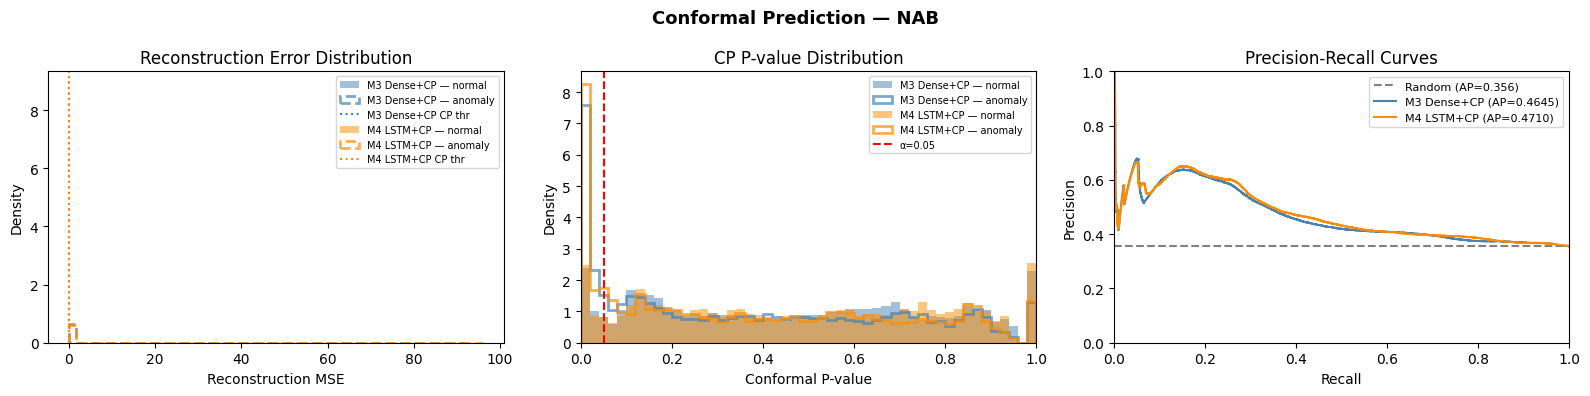

  Saved → outputs/cp_nab_analysis.png


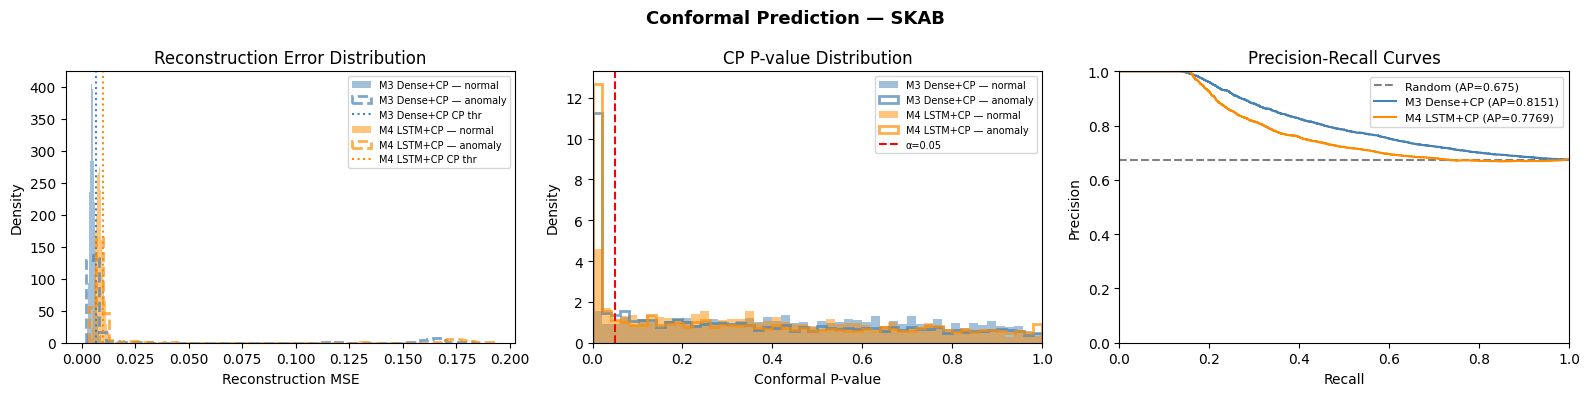

  Saved → outputs/cp_skab_analysis.png


In [13]:
warnings.filterwarnings("ignore")

for ds_name in sorted(set(list(m3_results.keys()) + list(m4_results.keys()))):
    y_test = data[ds_name]["y_test"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Conformal Prediction — {ds_name}", fontsize=13, fontweight="bold")

    # ── 1. Score distributions ────────────────────────────────────────────────
    ax = axes[0]
    ax.set_title("Reconstruction Error Distribution")
    for label, res, color in [
        ("M3 Dense+CP", m3_results.get(ds_name, {}), "steelblue"),
        ("M4 LSTM+CP",  m4_results.get(ds_name, {}), "darkorange"),
    ]:
        if not res:
            continue
        ts = res["test_scores"]
        ax.hist(ts[y_test == 0], bins=60, alpha=0.5,
                color=color, label=f"{label} — normal", density=True)
        ax.hist(ts[y_test == 1], bins=60, alpha=0.7,
                color=color, label=f"{label} — anomaly", density=True, linestyle="--",
                histtype="step", linewidth=2)
        thr = res["metrics"]["threshold"]
        ax.axvline(thr, color=color, linestyle=":", linewidth=1.5,
                   label=f"{label} CP thr")
    ax.set_xlabel("Reconstruction MSE")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

    # ── 2. P-value distributions ──────────────────────────────────────────────
    ax = axes[1]
    ax.set_title("CP P-value Distribution")
    for label, res, color in [
        ("M3 Dense+CP", m3_results.get(ds_name, {}), "steelblue"),
        ("M4 LSTM+CP",  m4_results.get(ds_name, {}), "darkorange"),
    ]:
        if not res:
            continue
        pv = res["p_values"]
        ax.hist(pv[y_test == 0], bins=50, alpha=0.5,
                color=color, label=f"{label} — normal", density=True)
        ax.hist(pv[y_test == 1], bins=50, alpha=0.7,
                color=color, label=f"{label} — anomaly", density=True,
                histtype="step", linewidth=2)
    ax.axvline(ALPHA, color="red", linestyle="--", label=f"α={ALPHA}", linewidth=1.5)
    ax.set_xlabel("Conformal P-value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)

    # ── 3. PR curves ──────────────────────────────────────────────────────────
    ax = axes[2]
    ax.set_title("Precision-Recall Curves")
    baseline = y_test.mean()
    ax.axhline(baseline, color="grey", linestyle="--", label=f"Random (AP={baseline:.3f})")
    for label, res, color in [
        ("M3 Dense+CP", m3_results.get(ds_name, {}), "steelblue"),
        ("M4 LSTM+CP",  m4_results.get(ds_name, {}), "darkorange"),
    ]:
        if not res:
            continue
        prec, rec, _ = precision_recall_curve(y_test, res["test_scores"])
        auc_pr = res["metrics"]["auc_pr"]
        ax.plot(rec, prec, color=color, label=f"{label} (AP={auc_pr:.4f})", linewidth=1.5)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"cp_{ds_name.lower()}_analysis.png")
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {out_path}")


---
## Section 10 — Save Results

In [14]:
# Load existing, append M3 / M4, write back
try:
    with open(RESULTS_FILE) as f:
        all_results = json.load(f)
except FileNotFoundError:
    all_results = {}
    print("WARNING: baseline_results.json not found — creating fresh.")

for ds_name in sorted(set(list(m3_results.keys()) + list(m4_results.keys()))):
    if ds_name not in all_results:
        all_results[ds_name] = {}

    for key, results in [("M3_dense_cp", m3_results), ("M4_lstm_cp", m4_results)]:
        if ds_name not in results:
            continue
        res = results[ds_name]
        m   = res["metrics"].copy()
        # strip arrays before serialising
        m.pop("alpha",              None)
        m.pop("empirical_coverage", None)
        all_results[ds_name][key] = {
            "hp":          res["hp"],
            "metrics":     m,
            "train_losses": res["train_losses"],
            "val_losses":   res["val_losses"],
        }

with open(RESULTS_FILE, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"Results saved → {RESULTS_FILE}")
for ds_name, methods in all_results.items():
    print(f"  {ds_name}: {list(methods.keys())}")


Results saved → outputs/baseline_results.json
  NAB: ['M2b_lstm_mcd_lowdrop', 'M3_dense_cp', 'M4_lstm_cp']
  SKAB: ['M2b_lstm_mcd_lowdrop', 'M3_dense_cp', 'M4_lstm_cp']


In [15]:
print("=" * 72)
print("  M3 & M4 — CONFORMAL PREDICTION  FINAL SUMMARY")
print("=" * 72)

try:
    with open(RESULTS_FILE) as f:
        saved = json.load(f)
except FileNotFoundError:
    saved = {}

for ds_name in sorted(set(list(m3_results.keys()) + list(m4_results.keys()))):
    print(f"\n  {ds_name}")
    print(f"  {'Method':<28} {'AUC-PR':>8} {'AUROC':>8} {'F1':>8} "
          f"{'Coverage':>10} {'AUROC(unc)':>12}")
    print(f"  {'─'*76}")

    for key, label, res in [
        ("B3_denseae",  "B3 Dense AE (det.)",    None),
        ("M1_dense_mcd","M1 Dense AE + MCD",      None),
        ("M3_dense_cp", "M3 Dense AE + CP  ← new", m3_results.get(ds_name)),
        ("M2_lstm_mcd", "M2 LSTM AE + MCD",       None),
        ("M4_lstm_cp",  "M4 LSTM AE + CP   ← new", m4_results.get(ds_name)),
    ]:
        if res is None:
            m = saved.get(ds_name, {}).get(key, {}).get("metrics", {})
        else:
            m = res.get("metrics", {})
        ap  = m.get("auc_pr",    float("nan"))
        ar  = m.get("auroc",     float("nan"))
        f1  = m.get("f1",        float("nan"))
        cov = m.get("mean_unc",  float("nan"))
        au  = m.get("auroc_unc", float("nan"))
        cov_str = f"{cov:.4f}" if not (isinstance(cov, float) and cov != cov) else "  —"
        print(f"  {label:<28} {ap:>8.4f} {ar:>8.4f} {f1:>8.4f} {cov_str:>10} {au:>12.4f}")

print("\n" + "=" * 72)
print(f"  Plots   → {OUTPUT_DIR}/")
print(f"  Models  → {CKPT_DIR}/")
print(f"  Results → {RESULTS_FILE}")
print("=" * 72)
print("\nNote: 'Coverage' for CP = empirical coverage on normal test samples")
print("      (should be ≥ 0.95 to validate the formal CP guarantee)")
print("      'Coverage' for MCD = mean_unc (uncertainty magnitude — different metric)")


  M3 & M4 — CONFORMAL PREDICTION  FINAL SUMMARY

  NAB
  Method                         AUC-PR    AUROC       F1   Coverage   AUROC(unc)
  ────────────────────────────────────────────────────────────────────────────
  B3 Dense AE (det.)                nan      nan      nan          —          nan
  M1 Dense AE + MCD                 nan      nan      nan          —          nan
  M3 Dense AE + CP  ← new        0.4645   0.5968   0.3176     0.9230       0.5969
  M2 LSTM AE + MCD                  nan      nan      nan          —          nan
  M4 LSTM AE + CP   ← new        0.4710   0.6045   0.3209     0.9237       0.6045

  SKAB
  Method                         AUC-PR    AUROC       F1   Coverage   AUROC(unc)
  ────────────────────────────────────────────────────────────────────────────
  B3 Dense AE (det.)                nan      nan      nan          —          nan
  M1 Dense AE + MCD                 nan      nan      nan          —          nan
  M3 Dense AE + CP  ← new        0.8151  